# Pipeline de Poda Estruturada de Modelos no CIFAR-10

Este notebook apresenta uma pipeline completa, modular e estruturada para a realização de **Poda Física (Pruning Estruturado)** em modelos de Deep Learning treinados no dataset CIFAR-10.

A poda estruturada consiste em remover fisicamente neurónios (em camadas densas) e filtros inteiros (em camadas convolucionais). Ao contrário da poda não-estruturada (que apenas zera pesos, mantendo a arquitetura original), a poda física resulta em ganhos reais de velocidade (latência reduzida), menor uso de memória RAM/VRAM e redução real do tamanho do ficheiro do modelo.

### Estrutura da Pipeline:
1. **Configuração e Imports**: Preparação do ambiente e importação das dependências.
2. **Configuração do Dispositivo**: Verificação do dispositivo de hardware (CPU/GPU) ativo.
3. **Carregamento dos Modelos Pré-treinados**: Carregamento dos modelos `CIFAR10MLP` e `CIFAR10VGG` base.
4. **Preparação dos Dados e Avaliação Inicial (Baseline)**: Medição inicial do desempenho (Acurácia, Latência, Contagem de Parâmetros) dos modelos não podados.
5. **Funções Core de Poda Física**: Definição dos algoritmos de corte estruturado para camadas Lineares e Convolucionais, integrando o ajuste automático de camadas adjacentes e camadas de Batch Normalization.
6. **Estratégia de Seleção baseada em Norma L1**: Algoritmo de decisão baseado na magnitude da norma L1 dos pesos para identificar quais canais/neurónios são menos importantes e podem ser descartados.
7. **Pipelines de Poda Estruturada**: Aplicação sistemática e sequencial da poda em todos os blocos internos do MLP e da VGG-11.
8. **Execução e Teste da Pipeline de Poda**: Aplicação da poda de 30% nos modelos base.
9. **Avaliação Comparativa dos Resultados**: Comparação direta dos modelos antes e depois da poda, analisando o trade-off entre Acurácia, Velocidade e Redução de Tamanho.
10. **Visualização de Predições em Tempo Real**: Exibição de classificações qualitativas após a poda.

In [11]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader

# Importar arquiteturas e funções utilitárias do utils.py
from utils import CIFAR10MLP, CIFAR10VGG, evaluate_model, compute_metrics, classes

# Adicionar suporte para carregar modelos de forma segura no PyTorch moderno
torch.serialization.add_safe_globals([CIFAR10MLP, CIFAR10VGG])

## 1. Configuração do Dispositivo e Ambiente

Configuramos o dispositivo de computação ativo (`CUDA` para aceleração por GPU se disponível, caso contrário `CPU`) e inspecionamos os recursos de hardware disponíveis.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de computação ativo: {device}")

if device.type == 'cuda':
    print(f"Modelo da GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Alocada Inicialmente: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

Dispositivo de computação ativo: cpu


## 2. Carregamento dos Modelos Pré-treinados

Carregamos os pesos dos modelos salvos no diretório `model_dir/`. Estes modelos servirão como nossa referência (baseline) de acurácia e eficiência computacional.

In [13]:
def carregar_modelo_treinado(arquitetura, checkpoint_path):
    if not Path(checkpoint_path).exists():
        raise FileNotFoundError(f"O ficheiro {checkpoint_path} não foi encontrado. Certifique-se de que o modelo foi treinado previamente.")
    
    # Carregar o modelo completo
    model = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = model.to(device)
    model.eval() 
    
    print(f"-> Modelo {arquitetura} carregado com sucesso a partir de '{checkpoint_path}'")
    return model

# Carregar os modelos base
modelo_mlp_base = carregar_modelo_treinado("MLP", "model_dir/cifar_mlp.pt")
modelo_vgg_base = carregar_modelo_treinado("VGG", "model_dir/cifar_vgg.pt")

-> Modelo MLP carregado com sucesso a partir de 'model_dir/cifar_mlp.pt'
-> Modelo VGG carregado com sucesso a partir de 'model_dir/cifar_vgg.pt'


## 3. Preparação dos Dados e Avaliação Inicial (Baseline)

Carregamos o conjunto de dados de teste (CIFAR-10) usando as transformações normalizadas consistentes com o treino. De seguida, definimos a função para avaliar o desempenho preditivo (Acurácia) e o custo computacional (Latência e número total de parâmetros ativos).

In [14]:
# 1. Preparar os dados de teste (CIFAR-10)
transform_test = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# 2. Função de avaliação de desempenho e custo
def avaliar_desempenho_computacional(model, dataloader, nome_modelo):
    model.eval()
    correct = 0
    total = 0
    
    # Contar apenas os parâmetros ativos (não-nulos / que requerem gradiente)
    params_ativos = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Medir latência de inferência
    inicio_tempo = time.time()
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    latencia_total = time.time() - inicio_tempo
    accuracy = 100 * correct / total
    
    print(f"[{nome_modelo}] Accuracy: {accuracy:.2f}% | Parâmetros: {params_ativos:,} | Tempo Total: {latencia_total:.3f}s")
    return accuracy, params_ativos, latencia_total

# 3. Executar a avaliação Baseline
print("=== Avaliação Inicial (Sem Poda) ===")
acc_mlp_base, params_mlp_base, tempo_mlp_base = avaliar_desempenho_computacional(modelo_mlp_base, testloader, "MLP (Base)")
acc_vgg_base, params_vgg_base, tempo_vgg_base = avaliar_desempenho_computacional(modelo_vgg_base, testloader, "VGG (Base)")

=== Avaliação Inicial (Sem Poda) ===
[MLP (Base)] Accuracy: 57.41% | Parâmetros: 8,928,778 | Tempo Total: 14.194s
[VGG (Base)] Accuracy: 77.28% | Parâmetros: 9,493,770 | Tempo Total: 16.411s


## 4. Funções de Poda Física (Estruturada)

Estas funções são responsáveis pela **modificação estrutural (in-place)** dos tensores do PyTorch. Quando podamos um canal ou neurónio, não basta colocar os pesos a zero: é preciso remover essa linha/coluna da matriz de pesos, encolher as estatísticas do `BatchNorm` correspondente e reduzir as dimensões de entrada da camada seguinte.

- **`podar_bloco_linear_fisico`**: Remove neurónios (linhas de saída de uma camada densa), ajusta o `BatchNorm1d` associado e a dimensão de entrada da camada densa seguinte.
- **`podar_bloco_conv_fisico`**: Remove filtros inteiros (canais de saída de uma camada de convolução 2D), ajusta o `BatchNorm2d` associado e reconfigura os canais de entrada da próxima convolução (ou camada linear pós-flatten).

In [15]:
def podar_bloco_linear_fisico(camada_linear, camada_bn, camada_seguinte, indices_para_manter):
    """
    Remove neurónios de uma camada Linear, ajustando o BatchNorm1d e a camada seguinte.
    """
    device_atual = camada_linear.weight.device
    idx = torch.tensor(indices_para_manter, device=device_atual)
    
    with torch.no_grad():
        # 1. Cortar a Camada Atual
        camada_linear.weight.data = camada_linear.weight.data[idx, :]
        if camada_linear.bias is not None:
            camada_linear.bias.data = camada_linear.bias.data[idx]
        camada_linear.out_features = len(indices_para_manter)
        
        # 2. Cortar o BatchNorm1d
        if camada_bn is not None:
            camada_bn.weight.data = camada_bn.weight.data[idx]
            camada_bn.bias.data = camada_bn.bias.data[idx]
            camada_bn.running_mean.data = camada_bn.running_mean.data[idx]
            camada_bn.running_var.data = camada_bn.running_var.data[idx]
            camada_bn.num_features = len(indices_para_manter)
            
        # 3. Cortar a Entrada da Camada Seguinte
        if camada_seguinte is not None:
            camada_seguinte.weight.data = camada_seguinte.weight.data[:, idx]
            camada_seguinte.in_features = len(indices_para_manter)

def podar_bloco_conv_fisico(camada_conv, camada_bn, camada_seguinte, indices_para_manter):
    """
    Remove filtros de uma camada Conv2d, ajustando o BatchNorm2d e a camada seguinte.
    """
    device_atual = camada_conv.weight.device
    idx = torch.tensor(indices_para_manter, device=device_atual)
    
    with torch.no_grad():
        # 1. Cortar a Conv2d Atual
        camada_conv.weight.data = camada_conv.weight.data[idx, :, :, :]
        if camada_conv.bias is not None:
            camada_conv.bias.data = camada_conv.bias.data[idx]
        camada_conv.out_channels = len(indices_para_manter)
        
        # 2. Cortar o BatchNorm2d
        if camada_bn is not None:
            camada_bn.weight.data = camada_bn.weight.data[idx]
            camada_bn.bias.data = camada_bn.bias.data[idx]
            camada_bn.running_mean.data = camada_bn.running_mean.data[idx]
            camada_bn.running_var.data = camada_bn.running_var.data[idx]
            camada_bn.num_features = len(indices_para_manter)
            
        # 3. Cortar a Entrada da Camada Seguinte
        if camada_seguinte is not None:
            if isinstance(camada_seguinte, nn.Conv2d):
                camada_seguinte.weight.data = camada_seguinte.weight.data[:, idx, :, :]
                camada_seguinte.in_channels = len(indices_para_manter)
            elif isinstance(camada_seguinte, nn.Linear):
                # Caso a camada seguinte seja a primeira Linear do Classificador
                camada_seguinte.weight.data = camada_seguinte.weight.data[:, idx]
                camada_seguinte.in_features = len(indices_para_manter)

##  5. Estratégia de Seleção baseada em Magnitude (Norma L2)

Para decidir quais os neurónios/filtros a manter, calculamos a **Norma L2**


In [16]:
def calcular_indices_manter_l2(pesos, taxa_poda):
    """
    Calcula os índices dos pesos com maior norma L2 (Magnitude Euclidiana) para serem mantidos.
    
    Args:
        pesos (torch.Tensor): Tensor de pesos da camada.
        taxa_poda (float): Fração de canais/neurónios a serem removidos (entre 0 e 1).
    
    Returns:
        list: Índices das unidades a manter.
    """
    # Dimensões para calcular a norma:
    # Conv2d -> [out, in, H, W] | Linear -> [out, in]
    dims_colapsar = list(range(1, pesos.dim()))
    
    # Calcular norma L2 de cada canal/neurónio de saída
    # Eleva-se ao quadrado, soma-se nas dimensões colapsadas, e extrai-se a raiz quadrada
    l2_norms = torch.sqrt(torch.sum(pesos ** 2, dim=dims_colapsar))
    
    n_total = len(l2_norms)
    n_remover = int(n_total * taxa_poda)
    n_manter = n_total - n_remover
    
    # Garantir que mantemos pelo menos 1 canal/neurónio
    n_manter = max(1, n_manter)
    
    # Obter os índices dos maiores valores (os que mantemos)
    _, indices_manter = torch.topk(l2_norms, n_manter, largest=True, sorted=True)
    
    # Retornar como lista de inteiros ordenados
    return sorted(indices_manter.cpu().tolist())

## 6. Pipelines Estruturadas para Execução da Poda

Criamos agora funções de pipeline dedicadas para varrer e podar de forma segura os modelos `CIFAR10MLP` e `CIFAR10VGG`.

Estas funções identificam automaticamente as sequências de camadas (Linear/Conv -> BatchNorm -> Seguinte) e aplicam a poda com base em taxas específicas de descarte de forma totalmente automatizada.

In [17]:
def pipeline_poda_mlp(modelo_original, taxa_poda):
    """
    Aplica a poda estruturada a todas as camadas ocultas do CIFAR10MLP.
    """
    import copy
    modelo = copy.deepcopy(modelo_original)
    modelo.eval()
    
    print(f"\n--- Iniciando Poda Física no MLP (Taxa de Poda: {taxa_poda*100:.1f}%) ---")
    
    # Na arquitetura CIFAR10MLP:
    # classifier[1] (Linear) -> classifier[2] (BN) -> classifier[5] (Linear)
    # classifier[5] (Linear) -> classifier[6] (BN) -> classifier[9] (Linear)
    # classifier[9] (Linear) -> classifier[10] (BN) -> classifier[13] (Linear)
    camadas_para_podar = [
        (modelo.classifier[1], modelo.classifier[2], modelo.classifier[5]),
        (modelo.classifier[5], modelo.classifier[6], modelo.classifier[9]),
        (modelo.classifier[9], modelo.classifier[10], modelo.classifier[13])
    ]
    
    for i, (camada_linear, bn, camada_seg) in enumerate(camadas_para_podar):
        largura_original = camada_linear.out_features
        
        # Calcular quais neurónios manter
        indices_manter = calcular_indices_manter_l1(camada_linear.weight.data, taxa_poda)
        
        # Executar corte físico
        podar_bloco_linear_fisico(camada_linear, bn, camada_seg, indices_manter)
        
        print(f"Camada Linear Oculta {i+1}: Reduzida de {largura_original} para {len(indices_manter)} neurónios.")
        
    return modelo

def pipeline_poda_vgg(modelo_original, taxa_poda):
    """
    Aplica a poda estruturada a todas as camadas convolucionais internas da CIFAR10VGG.
    """
    import copy
    modelo = copy.deepcopy(modelo_original)
    modelo.eval()
    
    print(f"\n--- Iniciando Poda Física na VGG-11 (Taxa de Poda: {taxa_poda*100:.1f}%) ---")
    
    # Mapeamento de blocos convolucionais: (Conv, BatchNorm, Camada_Seguinte)
    blocos_conv = [
        (modelo.features[0],  modelo.features[1],  modelo.features[4]),
        (modelo.features[4],  modelo.features[5],  modelo.features[8]),
        (modelo.features[8],  modelo.features[9],  modelo.features[11]),
        (modelo.features[11], modelo.features[12], modelo.features[15]),
        (modelo.features[15], modelo.features[16], modelo.features[18]),
        (modelo.features[18], modelo.features[19], modelo.features[22]),
        (modelo.features[22], modelo.features[23], modelo.features[25]),
        (modelo.features[25], modelo.features[26], modelo.classifier[1])
    ]
    
    for i, (conv, bn, seg) in enumerate(blocos_conv):
        filtros_originais = conv.out_channels
        indices_manter = calcular_indices_manter_l1(conv.weight.data, taxa_poda)
        podar_bloco_conv_fisico(conv, bn, seg, indices_manter)
        print(f"Bloco Convolucional {i+1}: Reduzido de {filtros_originais} para {len(indices_manter)} filtros.")
        
    # Poda adicional no classificador linear da VGG
    largura_linear_original = modelo.classifier[1].out_features
    indices_linear_manter = calcular_indices_manter_l1(modelo.classifier[1].weight.data, taxa_poda)
    podar_bloco_linear_fisico(modelo.classifier[1], None, modelo.classifier[4], indices_linear_manter)
    print(f"Classificador Linear 1 (VGG): Reduzido de {largura_linear_original} para {len(indices_linear_manter)} neurónios.")
    
    return modelo

## 7. Execução da Pipeline de Poda

Definimos uma taxa de poda estrutural de **30%** (que remove 30% dos neurónios ocultos e filtros de convolução) e aplicamos a pipeline a ambos os modelos.

In [18]:
taxa_de_poda = 0.30  # 30% de descarte estrutural

# 1. Executar no MLP
modelo_mlp_podado = pipeline_poda_mlp(modelo_mlp_base, taxa_de_poda)

# 2. Executar na VGG
modelo_vgg_podado = pipeline_poda_vgg(modelo_vgg_base, taxa_de_poda)


--- Iniciando Poda Física no MLP (Taxa de Poda: 30.0%) ---
Camada Linear Oculta 1: Reduzida de 2048 para 1434 neurónios.
Camada Linear Oculta 2: Reduzida de 1024 para 717 neurónios.
Camada Linear Oculta 3: Reduzida de 512 para 359 neurónios.

--- Iniciando Poda Física na VGG-11 (Taxa de Poda: 30.0%) ---
Bloco Convolucional 1: Reduzido de 64 para 45 filtros.
Bloco Convolucional 2: Reduzido de 128 para 90 filtros.
Bloco Convolucional 3: Reduzido de 256 para 180 filtros.
Bloco Convolucional 4: Reduzido de 256 para 180 filtros.
Bloco Convolucional 5: Reduzido de 512 para 359 filtros.
Bloco Convolucional 6: Reduzido de 512 para 359 filtros.
Bloco Convolucional 7: Reduzido de 512 para 359 filtros.
Bloco Convolucional 8: Reduzido de 512 para 359 filtros.
Classificador Linear 1 (VGG): Reduzido de 512 para 359 neurónios.


## 8. Avaliação Comparativa dos Resultados

Medimos a acurácia, quantidade de parâmetros ativos e velocidade de inferência dos modelos podados para confrontá-los diretamente com o desempenho baseline obtido inicialmente.

In [19]:
print("=== Avaliação Pós-Poda (30% de Redução) ===")
acc_mlp_podado, params_mlp_podado, tempo_mlp_podado = avaliar_desempenho_computacional(modelo_mlp_podado, testloader, "MLP Podado")
acc_vgg_podado, params_vgg_podado, tempo_vgg_podado = avaliar_desempenho_computacional(modelo_vgg_podado, testloader, "VGG Podada")

# Exibir tabela e resumo dos resultados obtidos
def exibir_tabela_resumo(nome, acc_base, acc_pod, par_base, par_pod, t_base, t_pod):
    diff_acc = acc_pod - acc_base
    compressao_pars = (1 - par_pod / par_base) * 100
    speedup = (t_base / t_pod)
    
    print(f"\n================ RESUMO {nome} ================")
    print(f"Acurácia original: {acc_base:.2f}% | Acurácia pós-poda: {acc_pod:.2f}% (Variação: {diff_acc:+.2f}%)")
    print(f"Parâmetros originais: {par_base:,} | Parâmetros pós-poda: {par_pod:,} (Redução: {compressao_pars:.1f}%)")
    print(f"Tempo original: {t_base:.3f}s | Tempo pós-poda: {t_pod:.3f}s (Speedup de: {speedup:.2f}x)")
    print("==============================================")

exibir_tabela_resumo("MLP", acc_mlp_base, acc_mlp_podado, params_mlp_base, params_mlp_podado, tempo_mlp_base, tempo_mlp_podado)
exibir_tabela_resumo("VGG", acc_vgg_base, acc_vgg_podado, params_vgg_base, params_vgg_podado, tempo_vgg_base, tempo_vgg_podado)

=== Avaliação Pós-Poda (30% de Redução) ===
[MLP Podado] Accuracy: 50.13% | Parâmetros: 5,701,959 | Tempo Total: 8.085s
[VGG Podada] Accuracy: 20.74% | Parâmetros: 4,675,065 | Tempo Total: 12.270s

================ RESUMO MLP ================
Acurácia original: 57.41% | Acurácia pós-poda: 50.13% (Variação: -7.28%)
Parâmetros originais: 8,928,778 | Parâmetros pós-poda: 5,701,959 (Redução: 36.1%)
Tempo original: 14.194s | Tempo pós-poda: 8.085s (Speedup de: 1.76x)

================ RESUMO VGG ================
Acurácia original: 77.28% | Acurácia pós-poda: 20.74% (Variação: -56.54%)
Parâmetros originais: 9,493,770 | Parâmetros pós-poda: 4,675,065 (Redução: 50.8%)
Tempo original: 16.411s | Tempo pós-poda: 12.270s (Speedup de: 1.34x)


## 9. Visualização de Predições em Tempo Real

Para finalizar a pipeline, exibimos visualmente algumas predições em lote dos modelos podados para confirmar de forma qualitativa que os modelos continuam operacionais.

Predições qualitativas com o modelo MLP Podado:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5885309..1.8476003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7988247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.675763..1.8476003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38462442..1.6720077].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6466857..1.4542257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6697937..1.330576].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.704840

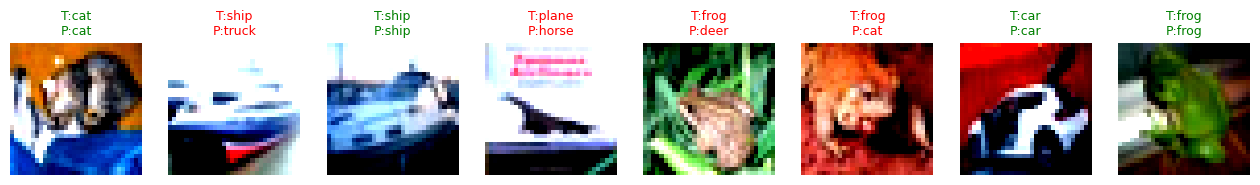

Predições qualitativas com o modelo VGG Podado:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5885309..1.8476003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7988247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.675763..1.8476003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38462442..1.6720077].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6466857..1.4542257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6697937..1.330576].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.704840

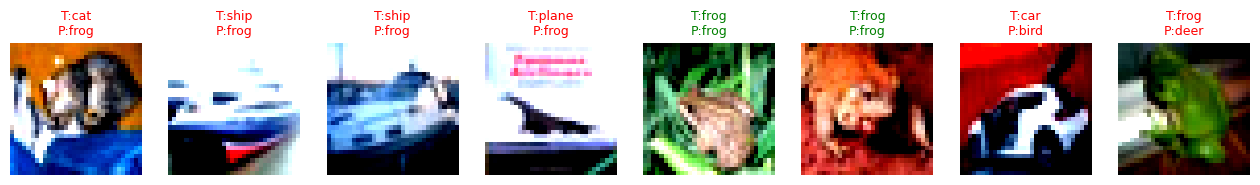

In [20]:
from utils import show_predictions

print("Predições qualitativas com o modelo MLP Podado:")
show_predictions(modelo_mlp_podado, testloader, n_images=8)

print("Predições qualitativas com o modelo VGG Podado:")
show_predictions(modelo_vgg_podado, testloader, n_images=8)